# Exercise 2. Graphs neural networks

## Exercise A: Invariant aggregation functions

### Q A.1

Permutation invariant functions include sum, product, mean, and max operations cf. slide 14.

As $f(x_1, ..., x_N)$ is not the same as $[f(x_1), ... , f(x_N)]$, concat is not an invariant permutation.

Thus 1, 2, and 3 are invariant permutations, but 4 is not.

## Exercise B: Simple graph neural networks

### Q B.1

It converges to the eigenvector, corresponding to the largest eigenvalue

### Q B.2

$W_{self}$ maps $D\rightarrow D$ so $32\times 32$ parameters.

$W_{neigh.}$ maps $D\rightarrow D$ so $32\times 32$ parameters.

$b$ is the bias vector of size $32$ dimensions.

$32\times 32 + 32\times 32 + 32 = 2080$ parameters for each message passing.

$2080 \times 5 = 10400$ parameters

## Exercise C: Programming exercise

### Q C.1


1784 nodes, with 7 discrete node labels.

The edges connects 2 nodes, where each index is the node ID. There's 3936 edges.

The train dataset contains 100 graphs (line 25). The last tensor is what graph each node belongs to.

In [ ]:
tensor([[1., 0., 0.,  ..., 0., 0., 0.],
        [1., 0., 0.,  ..., 0., 0., 0.],
        [1., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [1., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 1.,  ..., 0., 0., 0.],
        [0., 0., 1.,  ..., 0., 0., 0.]])
torch.Size([1784, 7])
tensor([[   0,    0,    1,  ..., 1781, 1782, 1783],
        [   1,    5,    0,  ..., 1780, 1779, 1778]])
torch.Size([2, 3936])
tensor([ 0,  0,  0,  ..., 99, 99, 99])
torch.Size([1784])

## Q C.2

The aggregate is just the neighbor states passed through message_net, but there's no outer MLP that wraps the sum of message_net.
The update step is a skip-connections (residual updates) from slide 20. It simply adds the message to the previous state (line 120).

x [num_nodes, 7] is the one-hot encoding atom-type for each node.

edge_index [2, num_edges] is the edge connectivity.

batch [num_nodes] is which graph each nodes belongs to.

out [num_graphs] is a single scalar that determines the mutagenicity (binary classification) of the molecule.

## Q C.3

loss function is BCEWithLogitsLoss.

optimizer is Adam.

learning rate is 1e-2.

LR scheduler is for adjusting the learning rate, during training. This can help prevent overshoots or slow convergence by dynamically changing the step size of the loss function.

Training and validation loss is computed in line 182-185. Accuracy is the sum of outs that's correctly greater than 0. Loss is the sum of the cross entropies.

The training is overfitting. train loss decrease while validation loss plateaus. Train accuracy is way higher than validation accuracy.

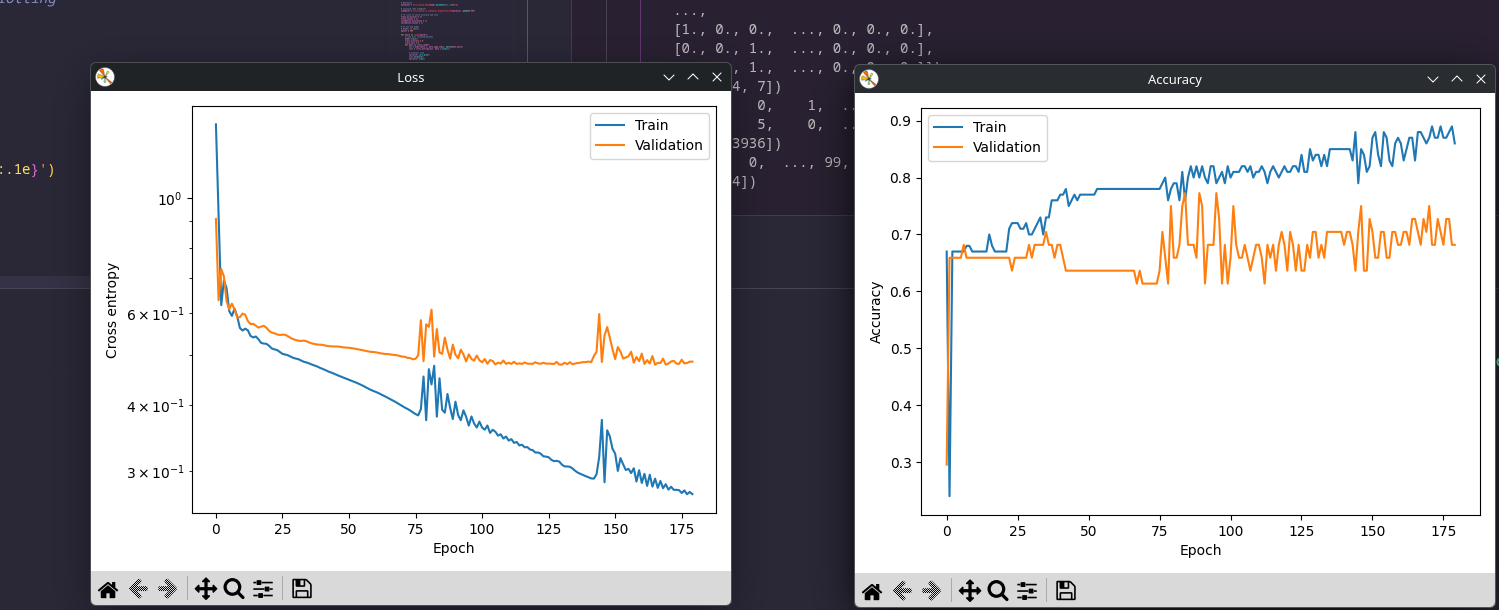

## Q C.4